In [1]:
# Step 2 — Part A: setup
import os

In [2]:
 # 1) Put your NREL key here for now (we'll move it to env later)
API_KEY = "Paste you API Key here"

In [3]:
# 2) Choose the state to start with (you can change later)
STATE = "CA"   # e.g., "MA", "NC", etc.

In [4]:
# 3) Ensure folders exist
os.makedirs("data/raw", exist_ok=True)


In [5]:
print("✅ Ready. API key set, STATE =", STATE, "| data/raw folder exists.")

✅ Ready. API key set, STATE = CA | data/raw folder exists.


In [6]:
# Step 2 — Part B: fetch + clean + save station snapshot for STATE

import math, time, requests, pandas as pd
from datetime import datetime

BASE = "https://developer.nrel.gov/api/alt-fuel-stations/v1.json"

def fetch_page(limit=200, offset=0, state=None):
    params = {
        "api_key": API_KEY,      # from Part A
        "fuel_type": "ELEC",
        "access": "public",      # public only
        "status": "E",           # existing/operational
        "country": "US",
        "limit": limit,
        "offset": offset
    }
    if state:
        params["state"] = state
    r = requests.get(BASE, params=params, timeout=30)
    r.raise_for_status()
    return r.json()

In [7]:
# 1) Discover total results for this STATE
meta = fetch_page(limit=1, offset=0, state=STATE)
total = meta["total_results"]
print(f"Total results for {STATE}: {total}")

Total results for CA: 18664


In [8]:
# 2) Pull all pages
LIMIT = 200
pages = math.ceil(total / LIMIT)
rows = []
for p in range(pages):
    js = fetch_page(limit=LIMIT, offset=p*LIMIT, state=STATE)
    rows.extend(js.get("fuel_stations", []))
    # polite pacing
    time.sleep(0.2)

print(f"Fetched {len(rows)} rows.")

Fetched 18800 rows.


In [9]:
# 3) Normalize & select fields
df = pd.DataFrame(rows)
keep = [
    "id","station_name","city","state","zip","latitude","longitude",
    "ev_connector_types","ev_network",
    "ev_dc_fast_num","ev_level1_evse_num","ev_level2_evse_num",
    "date_last_confirmed"
]
df = df[keep].copy()

In [10]:
# list->csv for connector types
df["ev_connector_types"] = df["ev_connector_types"].apply(lambda x: ",".join(x) if isinstance(x, list) else x)


In [11]:
# numeric EVSE counts
for c in ["ev_dc_fast_num","ev_level1_evse_num","ev_level2_evse_num"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

# dates & basic hygiene
df["date_last_confirmed"] = pd.to_datetime(df["date_last_confirmed"], errors="coerce")
df = df.dropna(subset=["latitude","longitude"])
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)


In [12]:
print("Preview:")
display(df.head(5))
print("Shape:", df.shape)

Preview:


,id,station_name,city,state,zip,latitude,longitude,ev_connector_types,ev_network,ev_dc_fast_num,ev_level1_evse_num,ev_level2_evse_num,date_last_confirmed
0,1523,Los Angeles Convention Center,Los Angeles,CA,90015,34.040539,-118.271387,J1772,Non-Networked,0,0,7,2023-01-10
1,6355,Scripps Green Hospital,La Jolla,CA,92037,32.899470,-117.243000,J1772,Non-Networked,0,0,1,2024-08-15
2,6405,Galpin Motors,Sepulveda,CA,91343,34.221665,-118.468371,J1772,Non-Networked,0,0,2,2025-06-06
3,6425,Galleria at Tyler,Riverside,CA,92503,33.909914,-117.459053,J1772,Non-Networked,0,0,4,2023-09-14
4,6505,City of Pasadena - Holly Street Garage,Pasadena,CA,91103,34.147620,-118.147111,J1772,Non-Networked,0,0,26,2025-06-06


Shape: (200, 13)


In [13]:
# 4) Save snapshot
ts = datetime.now().strftime("%Y%m%d_%H%M")
csv_path = f"data/raw/ev_stations_{STATE}_{ts}.csv"
parquet_path = csv_path.replace(".csv", ".parquet")

df.to_csv(csv_path, index=False)
df.to_parquet(parquet_path, index=False)

print(f"✅ Saved CSV -> {csv_path}")
print(f"✅ Saved Parquet -> {parquet_path}")

✅ Saved CSV -> data/raw/ev_stations_CA_20251015_1953.csv
✅ Saved Parquet -> data/raw/ev_stations_CA_20251015_1953.parquet


In [14]:
# Step 2 — Part C: explore station distribution by city

import pandas as pd
from pathlib import Path

# load the most recent file you just saved
latest = sorted(Path("data/raw").glob("ev_stations_*.csv"))[-1]
print("Loading:", latest)

df = pd.read_csv(latest)

# top 20 cities by station count
city_counts = (df["city"]
               .fillna("UNKNOWN")
               .str.title()
               .value_counts()
               .head(20))
print("\nTop 20 cities:")
display(city_counts)

# choose 1-2 pilot cities for modeling
pilot_cities = city_counts.head(2).index.tolist()
print(f"\n✅ Pilot cities chosen: {pilot_cities}")


Loading: data\raw\ev_stations_CA_20251015_1953.csv

Top 20 cities:


city
Los Angeles        10
Davis              10
Vacaville           9
San Luis Obispo     6
Sacramento          6
San Francisco       6
Pasadena            5
Fairfield           4
Riverside           4
Santa Monica        4
Northridge          4
Vallejo             3
San Jose            2
Ventura             2
Salinas             2
Oakland             2
Roseville           2
Victorville         2
Costa Mesa          2
Placerville         2
Name: count, dtype: int64


✅ Pilot cities chosen: ['Los Angeles', 'Davis']


In [15]:
pip install meteostat

Note: you may need to restart the kernel to use updated packages.


In [15]:
# Step 3 — Part B: fetch + save daily weather for pilot cities

from meteostat import Point, Daily
from datetime import datetime, timedelta
import pandas as pd
from pathlib import Path
import os

# --- inputs ---
PILOT_CITIES = ["Los Angeles", "Davis"]   # you can change later
start = datetime(2023, 1, 1)              # history start
end   = datetime.today() - timedelta(days=1)  # yesterday

# make sure raw folder exists
os.makedirs("data/raw", exist_ok=True)

# load latest stations snapshot
latest = sorted(Path("data/raw").glob("ev_stations_*.csv"))[-1]
df_stations = pd.read_csv(latest)

def city_weather(city_name: str) -> pd.DataFrame:
    # compute a simple "city centroid" from station coords
    sub = df_stations[df_stations["city"].str.title() == city_name.title()].copy()
    if sub.empty:
        raise ValueError(f"No stations found for city: {city_name}")

    lat, lon = sub["latitude"].mean(), sub["longitude"].mean()

    # fetch daily weather for city centroid
    p = Point(lat, lon)
    wx = Daily(p, start, end).fetch().reset_index()  # index -> 'time' column

    # keep useful columns & rename
    keep = ["time","tavg","tmin","tmax","prcp","snow","wdir","wspd","wpgt","pres","tsun"]
    wx = wx[[c for c in keep if c in wx.columns]].copy()
    wx = wx.rename(columns={"time":"date"})
    wx.insert(0, "city", city_name.title())

    return wx

all_wx = []
for c in PILOT_CITIES:
    try:
        wx = city_weather(c)
        all_wx.append(wx)
        # save per-city file
        tag = f"{start:%Y%m%d}_{end:%Y%m%d}"
        out_csv = f"data/raw/weather_{c.replace(' ','_')}_{tag}.csv"
        wx.to_csv(out_csv, index=False)
        print(f"✅ Saved {c}: {wx.shape[0]} days -> {out_csv}")
    except Exception as e:
        print(f"⚠️ {c}: {e}")

# optional: combined preview
if all_wx:
    df_wx = pd.concat(all_wx, ignore_index=True)
    display(df_wx.head())
    print("Combined shape:", df_wx.shape)


✅ Saved Los Angeles: 1018 days -> data/raw/weather_Los_Angeles_20230101_20251014.csv
✅ Saved Davis: 1018 days -> data/raw/weather_Davis_20230101_20251014.csv


,city,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,Los Angeles,2023-01-01,13.2,10.0,17.0,0.3,<NA>,<NA>,9.9,<NA>,1008.3,<NA>
1,Los Angeles,2023-01-02,12.1,9.0,14.0,5.5,<NA>,<NA>,7.4,<NA>,1015.4,<NA>
2,Los Angeles,2023-01-03,12.9,10.0,15.0,8.4,<NA>,<NA>,10.8,<NA>,1017.8,<NA>
3,Los Angeles,2023-01-04,15.0,13.9,17.0,17.5,<NA>,<NA>,7.8,<NA>,1018.7,<NA>
4,Los Angeles,2023-01-05,13.9,11.0,17.0,11.1,<NA>,<NA>,9.3,<NA>,1018.8,<NA>


Combined shape: (2036, 12)


In [16]:
# Step 3 — Part C (FIXED): combine weather + station metadata (city-level)

import pandas as pd
from pathlib import Path
import os

# --- Load station data (DOE) ---
latest_station = sorted(Path("data/raw").glob("ev_stations_*.csv"))[-1]
df_stn = pd.read_csv(latest_station)

# Normalize city names
df_stn["city"] = df_stn["city"].fillna("").str.title()

# Ensure numeric EVSE counts exist
for c in ["ev_level2_evse_num", "ev_dc_fast_num"]:
    if c not in df_stn.columns:
        df_stn[c] = 0
    df_stn[c] = pd.to_numeric(df_stn[c], errors="coerce").fillna(0).astype(int)

# Safe aggregation for connector types
def agg_connectors(series: pd.Series) -> str:
    vals = []
    for s in series.dropna():
        if isinstance(s, str):
            vals.extend([t.strip() for t in s.split(",") if t.strip()])
        elif isinstance(s, list):
            vals.extend([str(t).strip() for t in s if str(t).strip()])
    return ",".join(sorted(set(vals))) if vals else ""

stn_city = (
    df_stn.groupby("city", dropna=False)
          .agg(
              num_stations=("id", "count"),
              ev_level2_ports=("ev_level2_evse_num", "sum"),
              ev_dc_fast_ports=("ev_dc_fast_num", "sum"),
              connector_types=("ev_connector_types", agg_connectors),
          )
          .reset_index()
)

# --- Load weather data for all cities we saved ---
weather_files = list(Path("data/raw").glob("weather_*.csv"))
dfs = []
for f in weather_files:
    df = pd.read_csv(f, parse_dates=["date"])
    df["city"] = df["city"].fillna("").str.title()  # normalize to match stations
    dfs.append(df)

df_wx = pd.concat(dfs, ignore_index=True)

# Temporal features
df_wx["month"] = df_wx["date"].dt.month
df_wx["dayofweek"] = df_wx["date"].dt.dayofweek
df_wx["is_weekend"] = df_wx["dayofweek"].isin([5, 6]).astype(int)

# --- Merge city-level stations onto weather ---
df_final = df_wx.merge(stn_city, on="city", how="left")

# Save processed data
os.makedirs("data/processed", exist_ok=True)
out_csv = "data/processed/ev_city_weather_features.csv"
df_final.to_csv(out_csv, index=False)

print(f"✅ Saved combined dataset -> {out_csv}")
print("Shape:", df_final.shape)
display(df_final.head(10))


✅ Saved combined dataset -> data/processed/ev_city_weather_features.csv
Shape: (8122, 19)


,city,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,month,dayofweek,is_weekend,num_stations,ev_level2_ports,ev_dc_fast_ports,connector_types
0,Davis,2023-01-01,11.1,7.0,14.0,0.0,NaN,NaN,25.1,NaN,1011.0,NaN,1,6,1,10,24,1,"CHADEMO,J1772,NEMA520"
1,Davis,2023-01-02,6.0,3.0,8.0,13.6,NaN,NaN,5.5,NaN,1013.3,NaN,1,0,0,10,24,1,"CHADEMO,J1772,NEMA520"
2,Davis,2023-01-03,5.8,4.0,7.0,0.4,NaN,NaN,9.4,NaN,1016.9,NaN,1,1,0,10,24,1,"CHADEMO,J1772,NEMA520"
3,Davis,2023-01-04,10.0,6.0,15.0,28.8,NaN,NaN,21.5,NaN,1009.0,NaN,1,2,0,10,24,1,"CHADEMO,J1772,NEMA520"
4,Davis,2023-01-05,10.7,8.0,12.0,35.6,NaN,NaN,16.4,NaN,1011.7,NaN,1,3,0,10,24,1,"CHADEMO,J1772,NEMA520"
5,Davis,2023-01-06,10.2,8.0,15.0,0.3,NaN,NaN,8.3,NaN,1023.5,NaN,1,4,0,10,24,1,"CHADEMO,J1772,NEMA520"
6,Davis,2023-01-07,9.7,8.5,11.1,17.3,NaN,NaN,15.9,NaN,1016.3,NaN,1,5,1,10,24,1,"CHADEMO,J1772,NEMA520"
7,Davis,2023-01-08,11.3,8.7,15.0,15.3,NaN,NaN,20.1,NaN,1015.0,NaN,1,6,1,10,24,1,"CHADEMO,J1772,NEMA520"
8,Davis,2023-01-09,12.2,8.0,15.0,29.2,NaN,NaN,15.8,NaN,1007.8,NaN,1,0,0,10,24,1,"CHADEMO,J1772,NEMA520"
9,Davis,2023-01-10,10.5,9.0,12.0,13.5,NaN,NaN,19.8,NaN,1008.9,NaN,1,1,0,10,24,1,"CHADEMO,J1772,NEMA520"


In [17]:
# OCM pull with API key + headers + sanity test + city fetch

import os, time, requests, pandas as pd
from pathlib import Path

# 1) ⬅️⬅️ SET THESE TWO VALUES
OCM_API_KEY = "84f781dc-0113-4663-90c3-8a1b6bdaa794"      # replace
USER_EMAIL  = "shyampspk1998@gmail.com"       # replace (just so OCM can identify the client)

# 2) headers for OCM
headers = {
    "X-API-Key": OCM_API_KEY,
    "User-Agent": f"ev-forecast ({USER_EMAIL})"
}

# 3) quick sanity test around LA (small radius)
test_params = {
    "output": "json",
    "latitude": 34.05,        # Los Angeles approx
    "longitude": -118.24,
    "distance": 5,
    "distanceunit": "KM",
    "maxresults": 10,
    "compact": True,
    "verbose": False,
    "key": OCM_API_KEY
}
test_url = "https://api.openchargemap.io/v3/poi/"
resp = requests.get(test_url, params=test_params, headers=headers, timeout=30)
print("Sanity test status:", resp.status_code)
if resp.status_code != 200:
    print("Response text:", resp.text)
resp.raise_for_status()
print("Sanity test ok. Records:", len(resp.json()))

# 4) load DOE stations (to get city centroids)
stations_csv = sorted(Path("data/raw").glob("ev_stations_*.csv"))[-1]
df_stn = pd.read_csv(stations_csv)
df_stn["city"] = df_stn["city"].fillna("").str.title()

# 5) function to pull OCM around a city's centroid
def ocm_by_city(city, maxresults=500, distance_km=50):
    sub = df_stn[df_stn["city"] == city]
    if sub.empty:
        raise ValueError(f"No stations in DOE snapshot for city {city}")
    lat, lon = sub["latitude"].mean(), sub["longitude"].mean()

    params = {
        "output": "json",
        "latitude": float(lat),
        "longitude": float(lon),
        "distance": float(distance_km),
        "distanceunit": "KM",
        "maxresults": int(maxresults),
        "compact": True,
        "verbose": False,
        "key": OCM_API_KEY
    }

    # simple retry for 429 / transient errors
    for attempt in range(3):
        r = requests.get(test_url, params=params, headers=headers, timeout=30)
        if r.status_code == 429:
            wait = 2 ** attempt
            print(f"[{city}] 429 rate limit; sleeping {wait}s...")
            time.sleep(wait)
            continue
        if r.status_code != 200:
            print(f"[{city}] HTTP {r.status_code}: {r.text[:200]}")
        r.raise_for_status()
        data = r.json()
        break

    rows = []
    for d in data:
        addr = d.get("AddressInfo") or {}
        st = d.get("StatusType") or {}
        conn = d.get("Connections") or []
        rows.append({
            "ocm_id": d.get("ID"),
            "title": addr.get("Title"),
            "city": (addr.get("Town") or "").title(),
            "state": addr.get("StateOrProvince"),
            "lat": addr.get("Latitude"),
            "lon": addr.get("Longitude"),
            "status": st.get("IsOperational"),
            "status_title": st.get("Title"),
            "num_points": d.get("NumberOfPoints"),
            "date_last_update": d.get("DateLastStatusUpdate"),
            "usage_cost": d.get("UsageCost"),
            "connections": ";".join(sorted({str(c.get('ConnectionType', {}).get('Title') or '') for c in conn if c})),
            "power_kw_max": max([c.get("PowerKW") or 0 for c in conn], default=0),
            "network": (d.get("OperatorInfo") or {}).get("Title"),
        })
    return pd.DataFrame(rows)

# 6) fetch & save both pilot cities
os.makedirs("data/raw", exist_ok=True)
PILOT_CITIES = ["Los Angeles", "Davis"]

all_dfs = []
for c in PILOT_CITIES:
    df_city = ocm_by_city(c)
    out = f"data/raw/ocm_{c.replace(' ','_')}.csv"
    df_city.to_csv(out, index=False)
    all_dfs.append(df_city)
    print(f"✅ Saved OCM for {c}: {df_city.shape} -> {out}")

df_ocm = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
print("Combined OCM shape:", df_ocm.shape)
df_ocm.head()



Sanity test status: 200
Sanity test ok. Records: 10
✅ Saved OCM for Los Angeles: (500, 14) -> data/raw/ocm_Los_Angeles.csv
✅ Saved OCM for Davis: (500, 14) -> data/raw/ocm_Davis.csv
Combined OCM shape: (1000, 14)


,ocm_id,title,city,state,lat,lon,status,status_title,num_points,date_last_update,usage_cost,connections,power_kw_max,network
0,220488,RAP CHARGER2,Los Angeles,CA,34.022162,-118.351765,None,None,NaN,2025-06-24T07:08:00Z,None,,3.7,None
1,262356,3498 S Harcourt Ave,Los Angeles,CA,34.024839,-118.350681,None,None,NaN,2025-06-24T07:08:00Z,None,,3.7,None
2,328075,G&M OIL G&M #111,Los Angeles,CA,34.018642,-118.354961,None,None,NaN,2025-06-24T07:08:00Z,None,,50.0,None
3,122109,AT&T,Los Angeles,CA,34.018312,-118.354971,None,None,NaN,2019-12-24T09:11:00Z,None,,3.0,None
4,220521,5319 W Adams Blvd,Los Angeles,CA,34.032388,-118.359167,None,None,NaN,2025-06-24T07:08:00Z,None,,3.7,None


In [18]:
# Step 4 — Part B: build synthetic daily_sessions target

import numpy as np
import pandas as pd
from pathlib import Path

# Load processed city-weather dataset
weather_path = Path("data/processed/ev_city_weather_features.csv")
df_base = pd.read_csv(weather_path, parse_dates=["date"])

# Load OCM data for power + num_points
ocm_files = list(Path("data/raw").glob("ocm_*.csv"))
dfs = []
for f in ocm_files:
    df = pd.read_csv(f)
    df["city"] = df["city"].fillna("").str.title()
    dfs.append(df)
df_ocm = pd.concat(dfs, ignore_index=True)

# Aggregate to city-level
df_ocm_city = (
    df_ocm.groupby("city", dropna=False)
           .agg(
               total_points=("num_points", "sum"),
               avg_power_kw=("power_kw_max", "mean"),
               n_sites=("ocm_id", "count")
           )
           .reset_index()
)

# Merge OCM aggregates into base table
df = df_base.merge(df_ocm_city, on="city", how="left")

# --- simulate daily_sessions ---
np.random.seed(42)

# base intensity: proportional to number of points and average power
base_rate = (
    0.5 * df["total_points"].fillna(10) +
    0.2 * df["avg_power_kw"].fillna(7)
)

# weather modifiers
temp_factor = 1 - 0.01 * np.abs(df["tavg"].fillna(20) - 20)    # peak around 20 °C
rain_factor = np.exp(-0.15 * df["prcp"].fillna(0))             # heavy rain lowers use
weekend_boost = 1 + 0.15 * df["is_weekend"]

# combine all
df["daily_sessions"] = (
    base_rate * temp_factor * rain_factor * weekend_boost *
    np.random.normal(1.0, 0.1, len(df))
)

# clean up
df["daily_sessions"] = df["daily_sessions"].clip(lower=1).round(1)

# Save the feature-ready dataset
out_csv = "data/processed/ev_city_weather_demand.csv"
df.to_csv(out_csv, index=False)

print(f"✅ Created synthetic target and saved -> {out_csv}")
print("Shape:", df.shape)
display(df.head(10)[["city","date","tavg","prcp","num_stations","total_points","avg_power_kw","daily_sessions"]])


✅ Created synthetic target and saved -> data/processed/ev_city_weather_demand.csv
Shape: (8122, 23)


,city,date,tavg,prcp,num_stations,total_points,avg_power_kw,daily_sessions
0,Davis,2023-01-01,11.1,0.0,10,16.0,23.592157,14.0
1,Davis,2023-01-02,6.0,13.6,10,16.0,23.592157,1.4
2,Davis,2023-01-03,5.8,0.4,10,16.0,23.592157,10.9
3,Davis,2023-01-04,10.0,28.8,10,16.0,23.592157,1.0
4,Davis,2023-01-05,10.7,35.6,10,16.0,23.592157,1.0
5,Davis,2023-01-06,10.2,0.3,10,16.0,23.592157,10.7
6,Davis,2023-01-07,9.7,17.3,10,16.0,23.592157,1.1
7,Davis,2023-01-08,11.3,15.3,10,16.0,23.592157,1.4
8,Davis,2023-01-09,12.2,29.2,10,16.0,23.592157,1.0
9,Davis,2023-01-10,10.5,13.5,10,16.0,23.592157,1.6


In [28]:
# Step 5 A: load processed dataset & create train/validation split
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/processed/ev_city_weather_demand.csv", parse_dates=["date"])
print("Shape:", df.shape)

# select features
features = [
    "tavg", "tmin", "tmax", "prcp",
    "month", "dayofweek", "is_weekend",
    "num_stations", "ev_level2_ports", "ev_dc_fast_ports",
    "total_points", "avg_power_kw"
]
target = "daily_sessions"

df = df.dropna(subset=[target])

X = df[features]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, "Validation size:", X_val.shape)


Shape: (8122, 23)
Train size: (6497, 12) Validation size: (1625, 12)


In [29]:
# Step 5 B: train simple XGBoost regressor baseline
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_val)
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print(f"✅ Baseline model trained | MAE: {mae:.2f} | R²: {r2:.3f}")


✅ Baseline model trained | MAE: 2.13 | R²: 0.948


In [30]:
import joblib
joblib.dump(model, "data/processed/xgb_ev_model.pkl")
print("✅ Model saved successfully at data/processed/xgb_ev_model.pkl")


✅ Model saved successfully at data/processed/xgb_ev_model.pkl


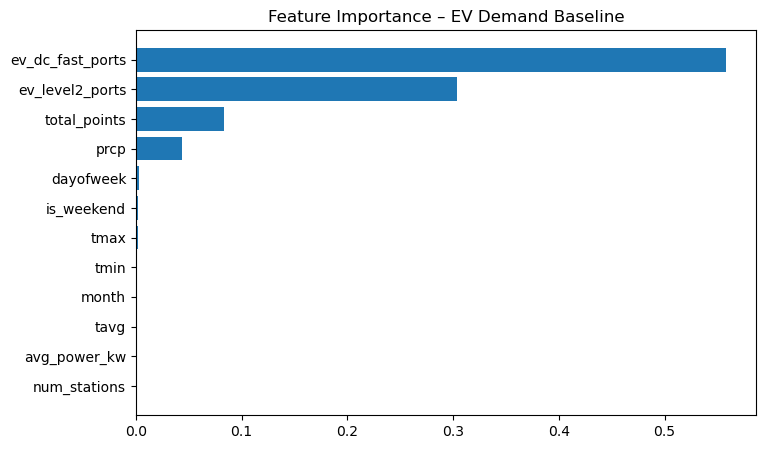

In [22]:
import matplotlib.pyplot as plt
import numpy as np

importance = model.feature_importances_
idx = np.argsort(importance)[::-1]
plt.figure(figsize=(8,5))
plt.barh(np.array(features)[idx], importance[idx])
plt.gca().invert_yaxis()
plt.title("Feature Importance – EV Demand Baseline")
plt.show()


In [23]:
{
  "tavg": 18.2,
  "tmin": 12.0,
  "tmax": 22.5,
  "prcp": 0.0,
  "month": 5,
  "dayofweek": 3,
  "is_weekend": 0,
  "num_stations": 80,
  "ev_level2_ports": 120,
  "ev_dc_fast_ports": 20,
  "total_points": 100,
  "avg_power_kw": 22
}


{'tavg': 18.2,
 'tmin': 12.0,
 'tmax': 22.5,
 'prcp': 0.0,
 'month': 5,
 'dayofweek': 3,
 'is_weekend': 0,
 'num_stations': 80,
 'ev_level2_ports': 120,
 'ev_dc_fast_ports': 20,
 'total_points': 100,
 'avg_power_kw': 22}

In [24]:
pip install fastapi

Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install --upgrade typing_extensions pydantic fastapi uvicorn


     -------------------------------------- 460.6/460.6 kB 1.9 MB/s eta 0:00:00
     ---------------------------------------- 2.0/2.0 MB 2.9 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.3
    Uninstalling pydantic_core-2.41.3:
      Successfully uninstalled pydantic_core-2.41.3
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.1
    Uninstalling pydantic-2.12.1:
      Successfully uninstalled pydantic-2.12.1
Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install --upgrade typing_extensions


Note: you may need to restart the kernel to use updated packages.


In [24]:
# src/api/app.py
from fastapi import FastAPI
import joblib
import pandas as pd
import xgboost as xgb
from pydantic import BaseModel

app = FastAPI(title="EV Demand Forecaster")

# Load model and feature list
MODEL_PATH = "data/processed/xgb_ev_model.pkl"
FEATURES = [
    "tavg","tmin","tmax","prcp","month","dayofweek","is_weekend",
    "num_stations","ev_level2_ports","ev_dc_fast_ports","total_points","avg_power_kw"
]

model = joblib.load(MODEL_PATH)

class EVRequest(BaseModel):
    tavg: float
    tmin: float
    tmax: float
    prcp: float
    month: int
    dayofweek: int
    is_weekend: int
    num_stations: float
    ev_level2_ports: float
    ev_dc_fast_ports: float
    total_points: float
    avg_power_kw: float

@app.post("/predict")
def predict(req: EVRequest):
    df = pd.DataFrame([req.dict()])[FEATURES]
    pred = model.predict(df)[0]
    return {"predicted_daily_sessions": round(float(pred), 2)}


In [31]:
import os
from pathlib import Path
import joblib

# 1) See where the notebook is running from
print("CWD:", os.getcwd())

# 2) Build an absolute path to data/processed inside THIS folder
project_root = Path.cwd()
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

model_path = processed_dir / "xgb_ev_model.pkl"

# 3) Save the model here (absolute path)
joblib.dump(model, model_path)

# 4) Print the exact file path so you can check it in File Explorer / CMD
print("✅ Saved model to:", model_path)


CWD: C:\Users\shyam\Videos\data science end to end\ev-forecast\notebooks
✅ Saved model to: C:\Users\shyam\Videos\data science end to end\ev-forecast\notebooks\data\processed\xgb_ev_model.pkl
